<a href="https://colab.research.google.com/github/AyushNegi785/bakanae-disease-detection/blob/main/mobilenetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# 1. Paths and Hyperparameters
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_FOLDS = 5

# 2. Collect all filepaths and labels
all_filepaths = []
all_labels = []
for label, folder_path in enumerate([PATH_BAKANAE, PATH_HEALTHY]):
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [ ]:
def build_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    model = models.Sequential([
        layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize containers for results
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_metrics = []
all_cms = []
roc_data = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"Training Fold {fold+1}...")
    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx])).map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_model()
    model.fit(train_ds, epochs=10, verbose=0)

    # Generate predictions for the validation step
    probs = model.predict(val_ds).ravel()
    y_pred = (probs > 0.5).astype(int)
    y_true = all_labels[val_idx]

    # Store data for the validation block
    fpr, tpr, _ = roc_curve(y_true, probs)
    fold_metrics.append({
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC': auc(fpr, tpr)
    })
    all_cms.append(confusion_matrix(y_true, y_pred))
    roc_data.append((fpr, tpr))

Training Fold 1...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step
Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
Training Fold 3...


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step



FINAL 5-FOLD AVERAGE PERFORMANCE
Average Accuracy:  0.9722
Average Precision: 0.9724
Average Recall:    0.9735
Average F1-Score:  0.9727
Average AUC-ROC:   0.9925


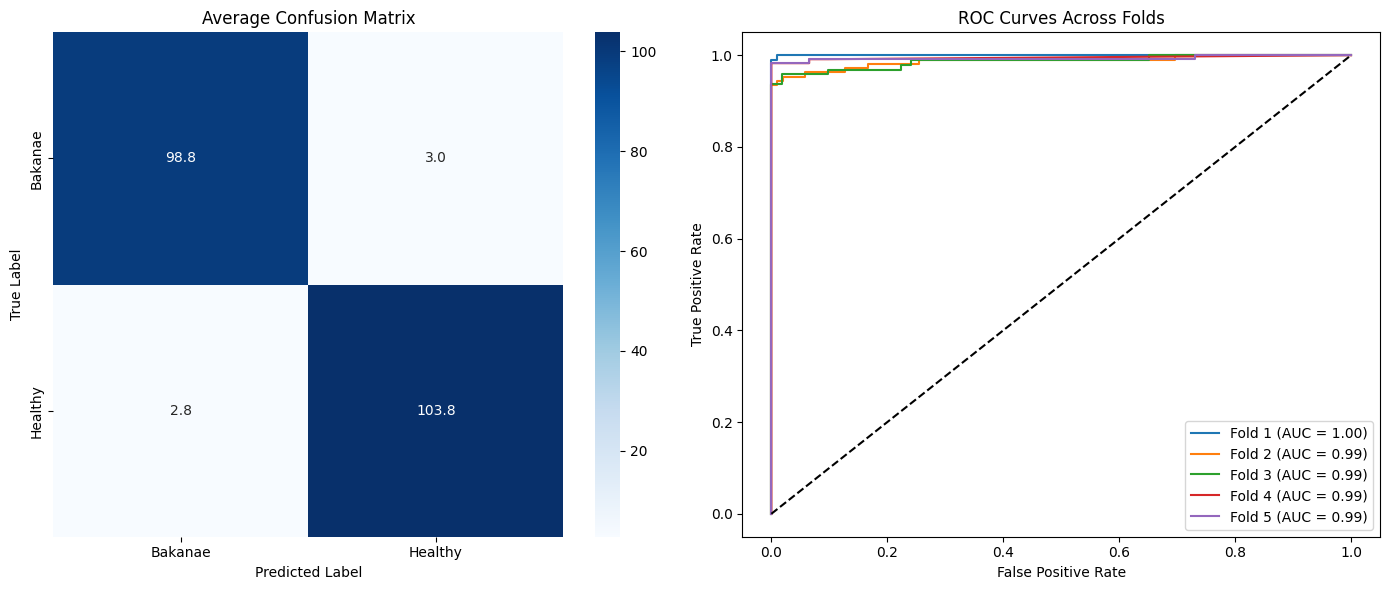

In [ ]:
# 1. Final Average Calculation
avg_metrics = pd.DataFrame(fold_metrics).mean()
avg_cm = np.mean(all_cms, axis=0)

print("\n" + "="*40)
print("FINAL 5-FOLD AVERAGE PERFORMANCE")
print("="*40)
print(f"Average Accuracy:  {avg_metrics['Accuracy']:.4f}")
print(f"Average Precision: {avg_metrics['Precision']:.4f}")
print(f"Average Recall:    {avg_metrics['Recall']:.4f}")
print(f"Average F1-Score:  {avg_metrics['F1-Score']:.4f}")
print(f"Average AUC-ROC:   {avg_metrics['AUC']:.4f}")
print("="*40)

# 2. Visualize Confusion Matrix and ROC Curves
plt.figure(figsize=(14, 6))

# Subplot: Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Average Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Subplot: ROC Curves
plt.subplot(1, 2, 2)
for i, (fpr, tpr) in enumerate(roc_data):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_metrics[i]["AUC"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves Across Folds')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # <--- Corrected this line
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. Load Filepaths ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



MOBILENET-V2 MODEL PARAMETERS


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)



--- MOBILENET-V2: FOLD 1/5 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step
Time -> Train: 897.58s | Test: 40.2877s
Stats -> Acc: 0.9809 | F1: 0.9802 | Recall: 1.0000


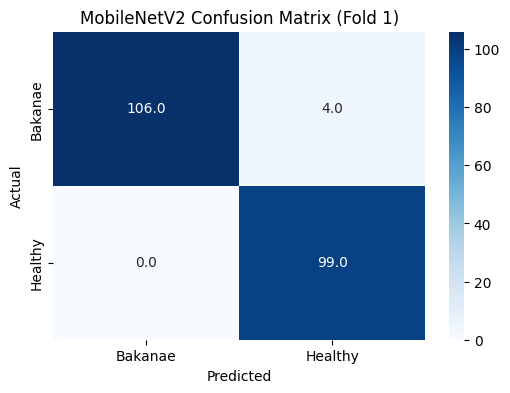


--- MOBILENET-V2: FOLD 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
Time -> Train: 731.55s | Test: 20.5098s
Stats -> Acc: 0.9665 | F1: 0.9665 | Recall: 0.9439


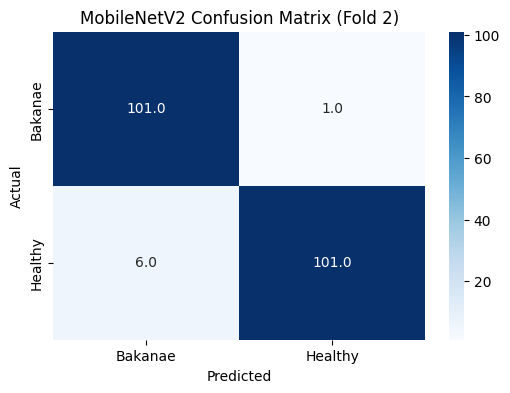


--- MOBILENET-V2: FOLD 3/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Time -> Train: 696.53s | Test: 20.4898s
Stats -> Acc: 0.9663 | F1: 0.9630 | Recall: 0.9479


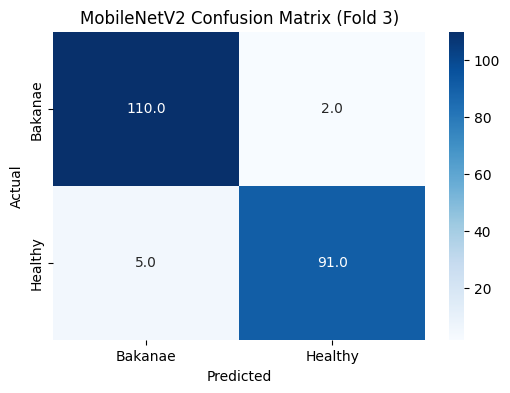


--- MOBILENET-V2: FOLD 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Time -> Train: 645.75s | Test: 20.4963s
Stats -> Acc: 0.9856 | F1: 0.9870 | Recall: 0.9828


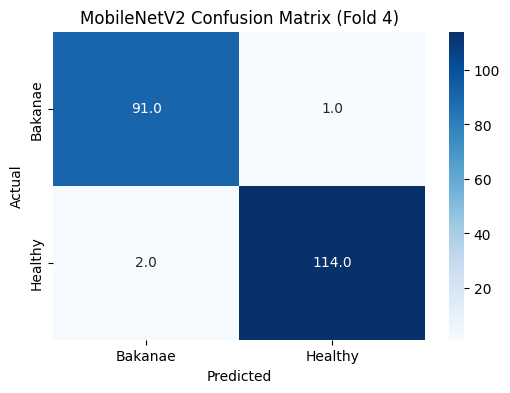


--- MOBILENET-V2: FOLD 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Time -> Train: 642.12s | Test: 17.7595s
Stats -> Acc: 0.9663 | F1: 0.9700 | Recall: 0.9826


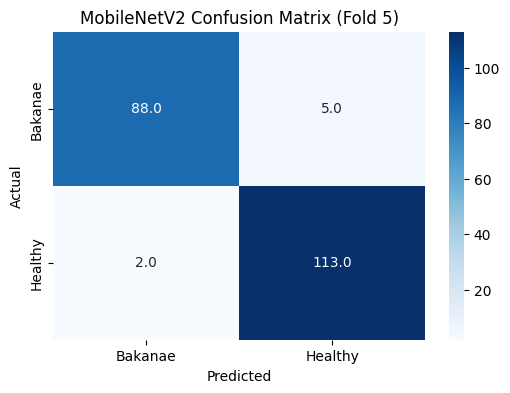

In [ ]:
def plot_cm_image(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def build_mobilenet_v2():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Show Model Complexity (Parameters)
temp_model = build_mobilenet_v2()
print("\n" + "="*50)
print("MOBILENET-V2 MODEL PARAMETERS")
temp_model.summary()
print("="*50 + "\n")

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- MOBILENET-V2: FOLD {fold+1}/{NUM_FOLDS} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx])).map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_mobilenet_v2()

    # Measure Training Time
    start_train = time.time()
    model.fit(train_ds, epochs=10, verbose=0)
    train_time = time.time() - start_train

    # Measure Testing/Inference Time
    start_test = time.time()
    y_probs = model.predict(val_ds).ravel()
    test_time = time.time() - start_test

    y_true = all_labels[val_idx]
    y_pred = (y_probs > 0.5).astype(int)

    acc, f1, rec = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred), recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)

    print(f"Time -> Train: {train_time:.2f}s | Test: {test_time:.4f}s")
    print(f"Stats -> Acc: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")

    plot_cm_image(cm, f'MobileNetV2 Confusion Matrix (Fold {fold+1})')

    all_cms.append(cm)
    roc_curves.append((fpr, tpr, fold_auc))
    fold_results.append({'ACC': acc, 'F1': f1, 'RECALL': rec, 'AUC': fold_auc, 'TRAIN_T': train_time, 'TEST_T': test_time})


##################################################
FINAL GLOBAL PERFORMANCE SUMMARY (MOBILENET-V2)
##################################################
Avg Accuracy:      0.9731
Avg F1-Score:      0.9733
Avg Recall:        0.9714
Avg AUC-ROC:       0.9937
Avg Training Time: 722.71s
Avg Inference Time:23.9086s
##################################################


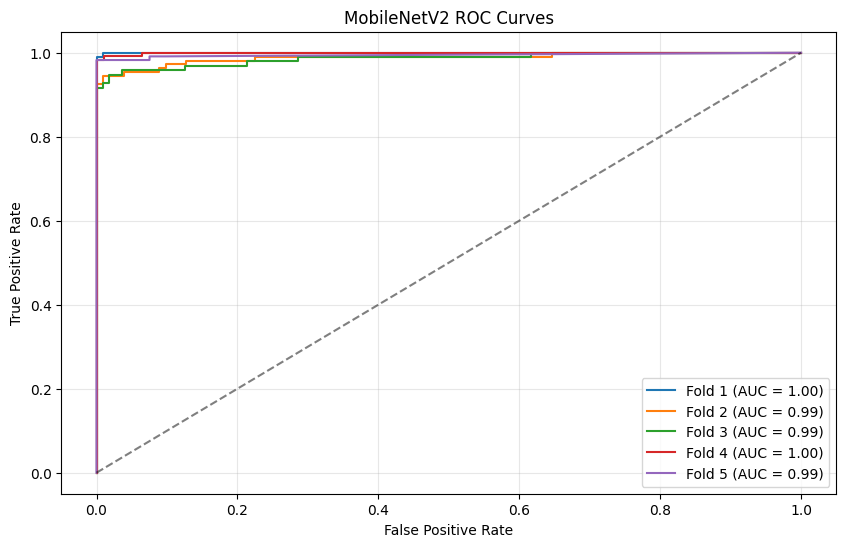

In [ ]:
results_df = pd.DataFrame(fold_results)
avg_cm = np.mean(all_cms, axis=0)

print("\n" + "#"*50)
print("FINAL GLOBAL PERFORMANCE SUMMARY (MOBILENET-V2)")
print("#"*50)
print(f"Avg Accuracy:      {results_df['ACC'].mean():.4f}")
print(f"Avg F1-Score:      {results_df['F1'].mean():.4f}")
print(f"Avg Recall:        {results_df['RECALL'].mean():.4f}")
print(f"Avg AUC-ROC:       {results_df['AUC'].mean():.4f}")
print(f"Avg Training Time: {results_df['TRAIN_T'].mean():.2f}s")
print(f"Avg Inference Time:{results_df['TEST_T'].mean():.4f}s")
print("#"*50)

# Visual Comparison of ROC
plt.figure(figsize=(10, 6))
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('MobileNetV2 ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()